In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)

sns.set_style("whitegrid")



In [4]:

fund_df = pd.read_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/fund_master_cleaned.csv"
)

nav_df = pd.read_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/nav_history_cleaned.csv"
)

txn_df = pd.read_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/investor_transactions_cleaned.csv"
)

perf_df = pd.read_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/scheme_performance_cleaned.csv"
)

portfolio_df = pd.read_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/raw/portfolio_holdings.csv"
)

print("All datasets loaded successfully")



All datasets loaded successfully


In [5]:

nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    errors="coerce"
)

txn_df["transaction_date"] = pd.to_datetime(
    txn_df["transaction_date"],
    errors="coerce"
)




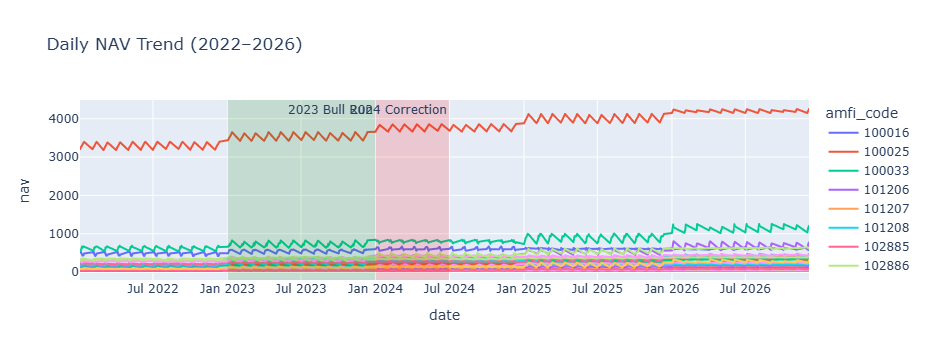

In [21]:

# 1. NAV TREND ANALYSIS


nav_trend = nav_df.groupby(
    ["date", "amfi_code"]
)["nav"].mean().reset_index()

fig = px.line(
    nav_trend,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15,
    line_width=0
)

fig.show()

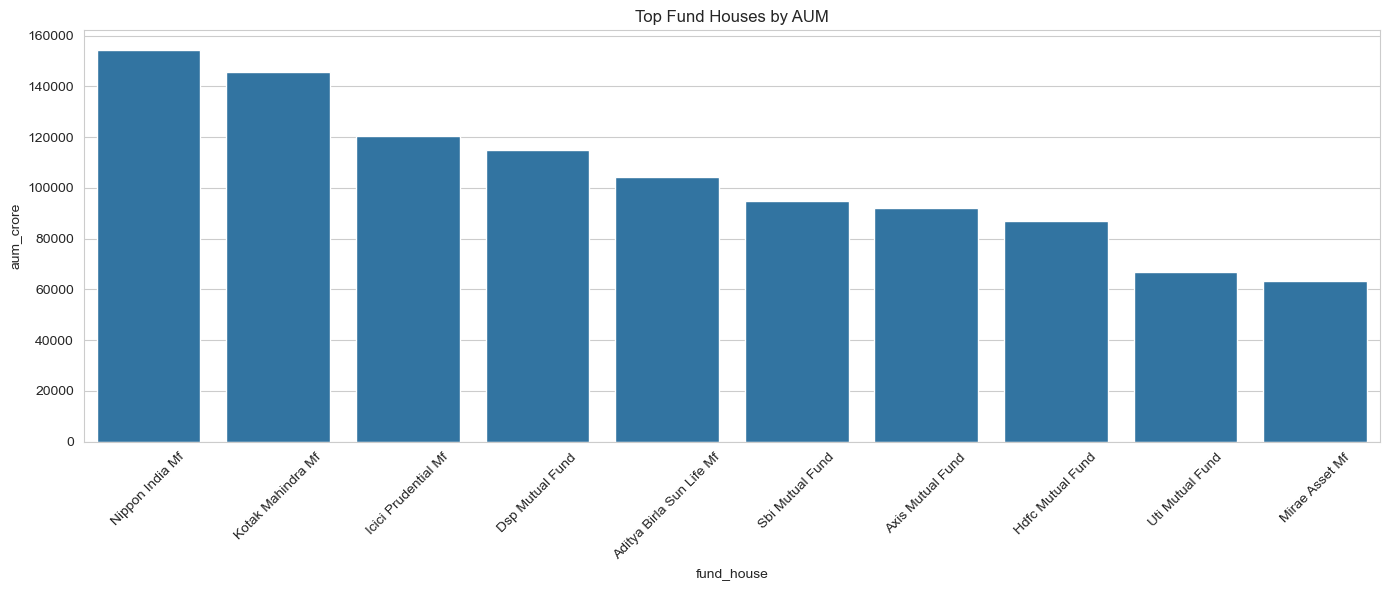

In [20]:

# 2. AUM GROWTH BAR CHART

aum_df = perf_df.groupby(
    "fund_house"
)["aum_crore"].sum().reset_index()

aum_df = aum_df.sort_values(
    by="aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=45)

plt.title("Top Fund Houses by AUM")

plt.tight_layout()

plt.show()

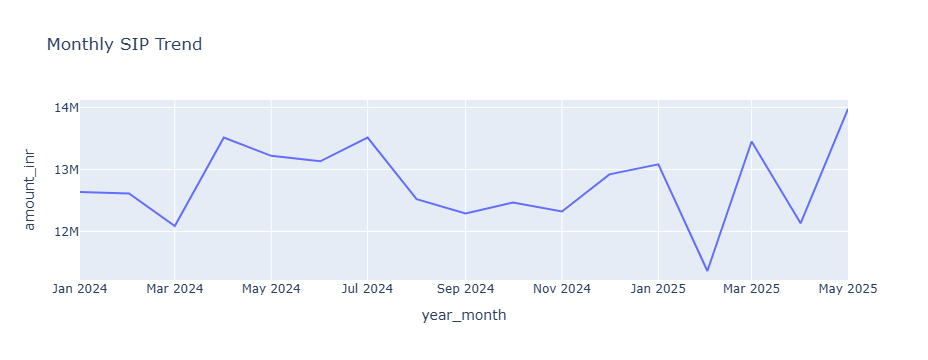

In [19]:

# 3. SIP INFLOW TREND

sip_df = txn_df[
    txn_df["transaction_type"].str.upper() == "SIP"
].copy()

sip_df["year_month"] = sip_df[
    "transaction_date"
].dt.to_period("M")

sip_monthly = sip_df.groupby(
    "year_month"
)["amount_inr"].sum().reset_index()

sip_monthly["year_month"] = (
    sip_monthly["year_month"].astype(str)
)

fig = px.line(
    sip_monthly,
    x="year_month",
    y="amount_inr",
    title="Monthly SIP Trend"
)

fig.show()

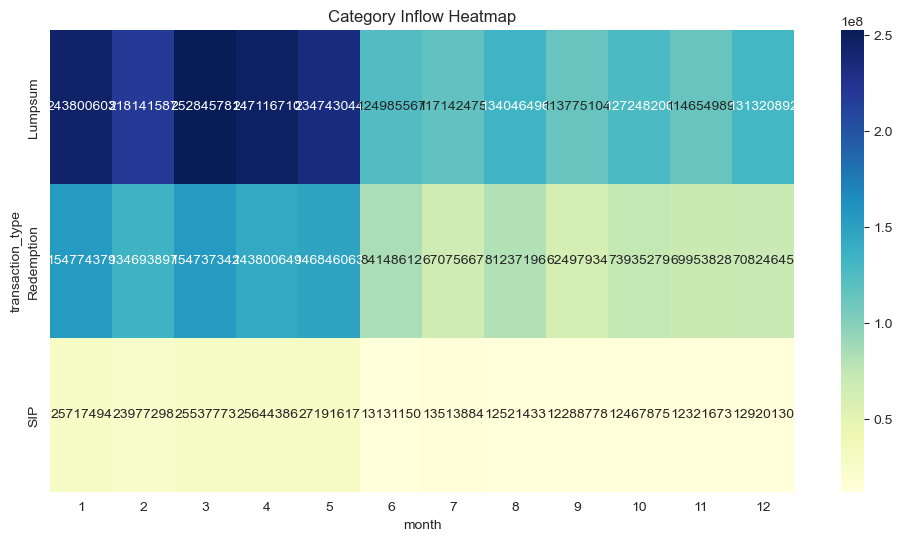

In [18]:

# 4. CATEGORY INFLOW HEATMAP

txn_df["month"] = txn_df[
    "transaction_date"
].dt.month

heat_df = txn_df.groupby(
    ["month", "transaction_type"]
)["amount_inr"].sum().reset_index()

pivot_heat = heat_df.pivot(
    index="transaction_type",
    columns="month",
    values="amount_inr"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_heat,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category Inflow Heatmap")

plt.show()

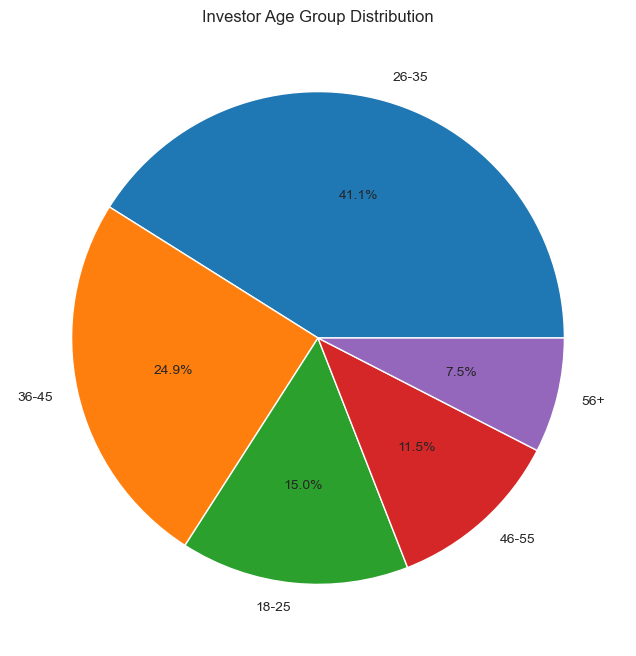

In [17]:

# 5. AGE GROUP DISTRIBUTION

age_counts = txn_df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

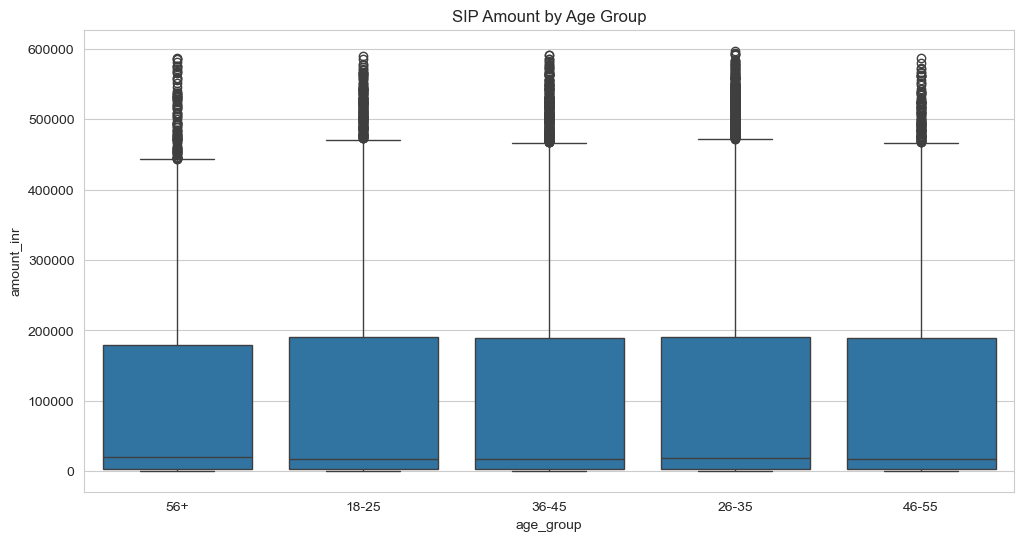

In [16]:

# 6. SIP AMOUNT BOXPLOT BY AGE GROUP


plt.figure(figsize=(12,6))

sns.boxplot(
    data=txn_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.show()

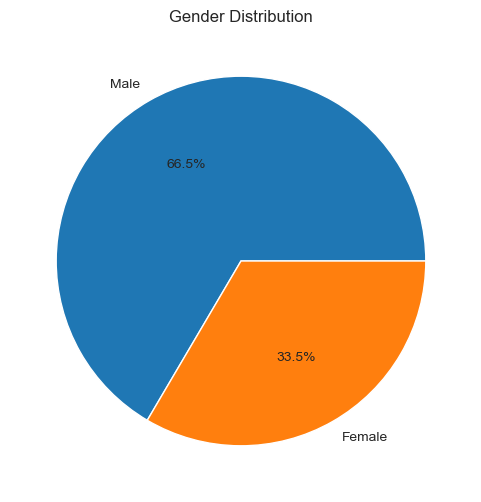

In [15]:

# 7. GENDER SPLIT

gender_counts = txn_df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()


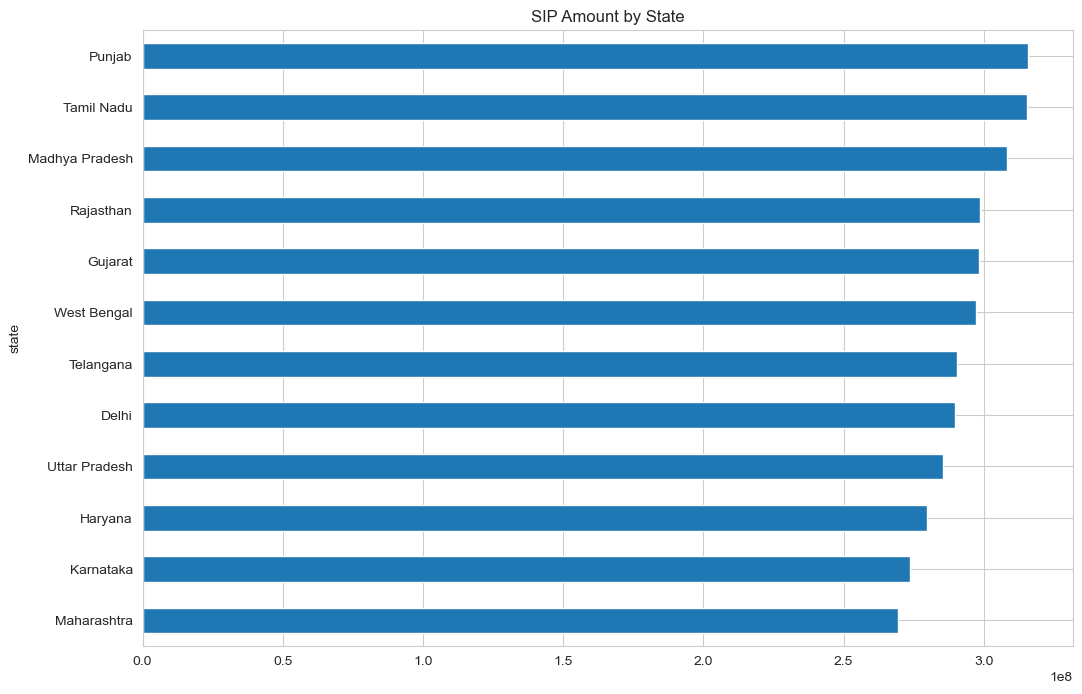

In [14]:

# 8. GEOGRAPHIC DISTRIBUTION

state_df = txn_df.groupby(
    "state"
)["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state_df.plot(kind="barh")

plt.title("SIP Amount by State")

plt.show()

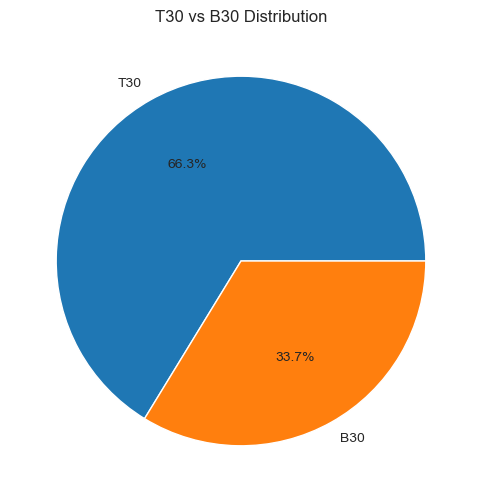

In [13]:

# 9. T30 VS B30 CITY TIER


tier_counts = txn_df["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.show()

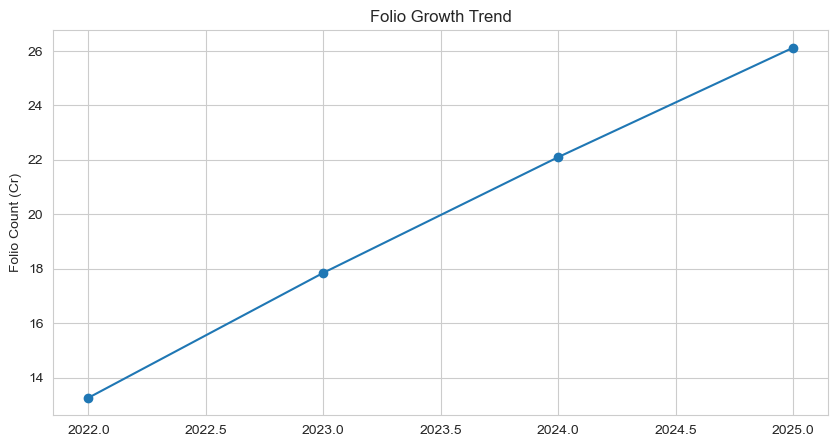

In [12]:

# 10. FOLIO GROWTH ANALYSIS


folio_growth = pd.DataFrame({
    "year": [2022, 2023, 2024, 2025],
    "folio_count": [13.26, 17.85, 22.10, 26.12]
})

plt.figure(figsize=(10,5))

plt.plot(
    folio_growth["year"],
    folio_growth["folio_count"],
    marker="o"
)

plt.title("Folio Growth Trend")

plt.ylabel("Folio Count (Cr)")

plt.show()


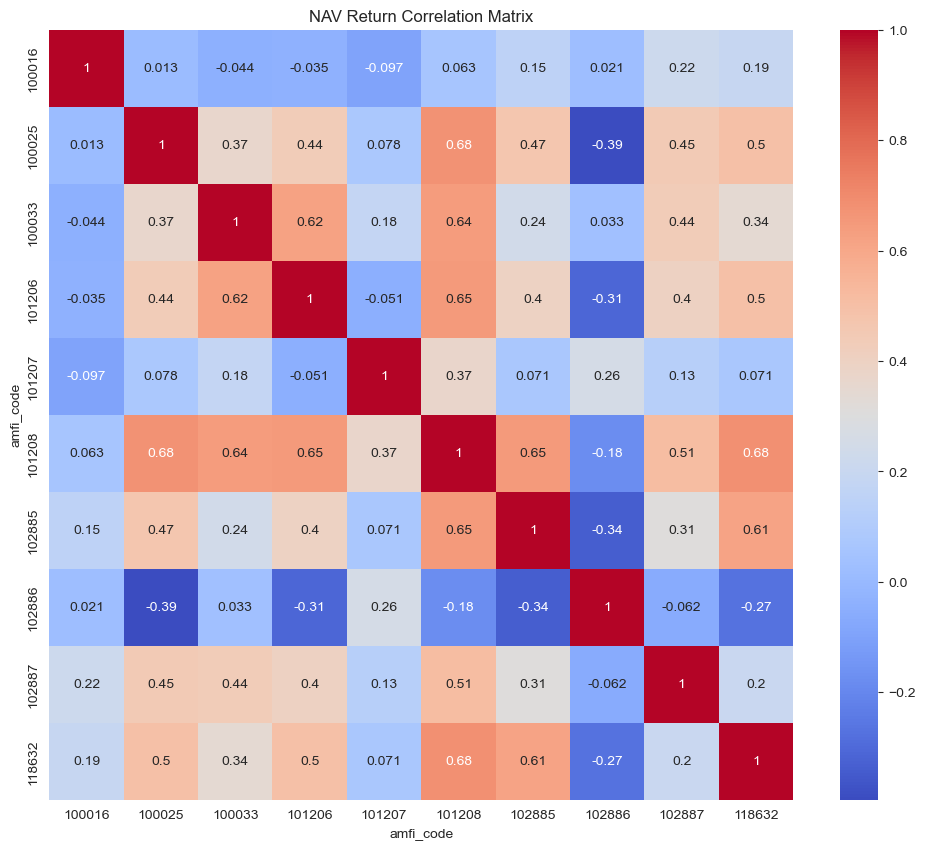

In [11]:

# 11. NAV RETURN CORRELATION MATRIX


selected_funds = nav_df[
    "amfi_code"
].unique()[:10]

corr_df = nav_df[
    nav_df["amfi_code"].isin(selected_funds)
]

pivot_nav = corr_df.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

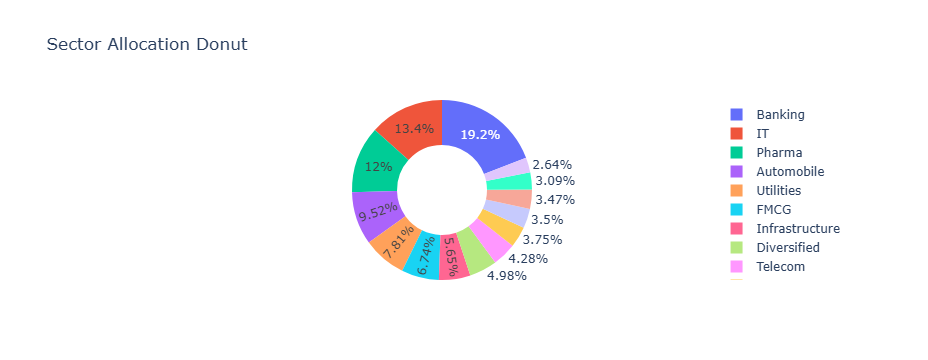

In [10]:

# 12. SECTOR ALLOCATION DONUT CHART


sector_alloc = portfolio_df.groupby(
    "sector"
)["weight_pct"].sum().reset_index()

fig = px.pie(
    sector_alloc,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Donut"
)

fig.show()

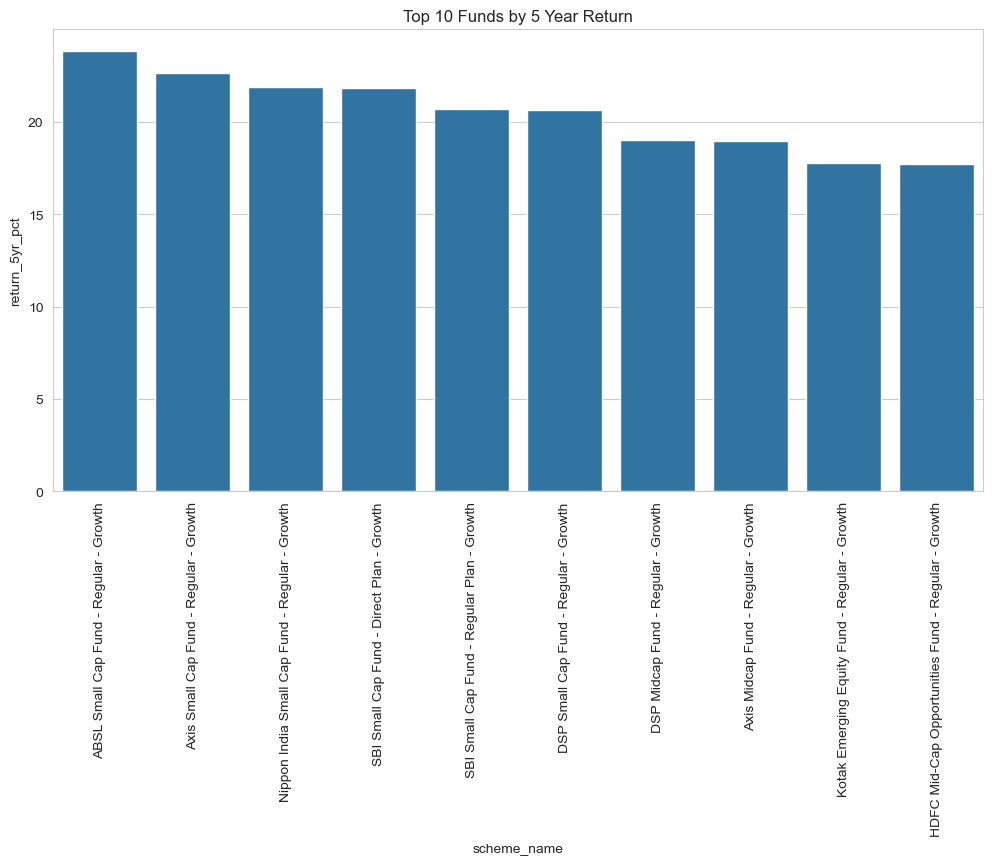

In [9]:

# 13. TOP 10 FUNDS BY 5 YEAR RETURN

top_returns = perf_df.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_returns,
    x="scheme_name",
    y="return_5yr_pct"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 5 Year Return")

plt.show()


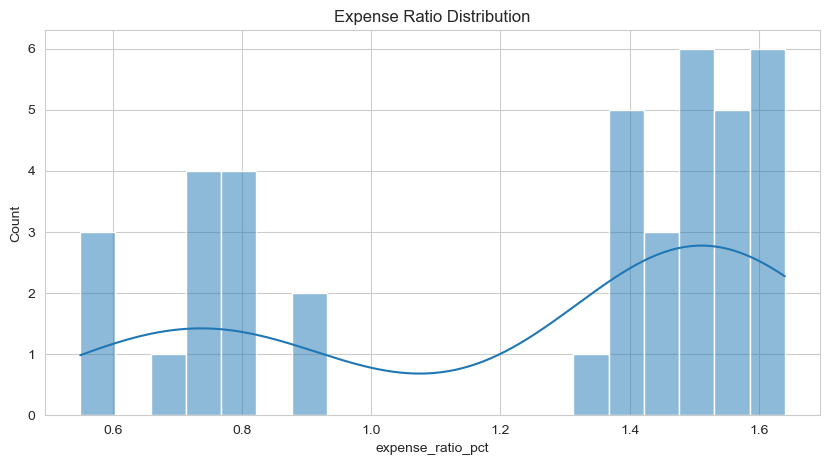

In [8]:

# 14. EXPENSE RATIO DISTRIBUTION

plt.figure(figsize=(10,5))

sns.histplot(
    perf_df["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

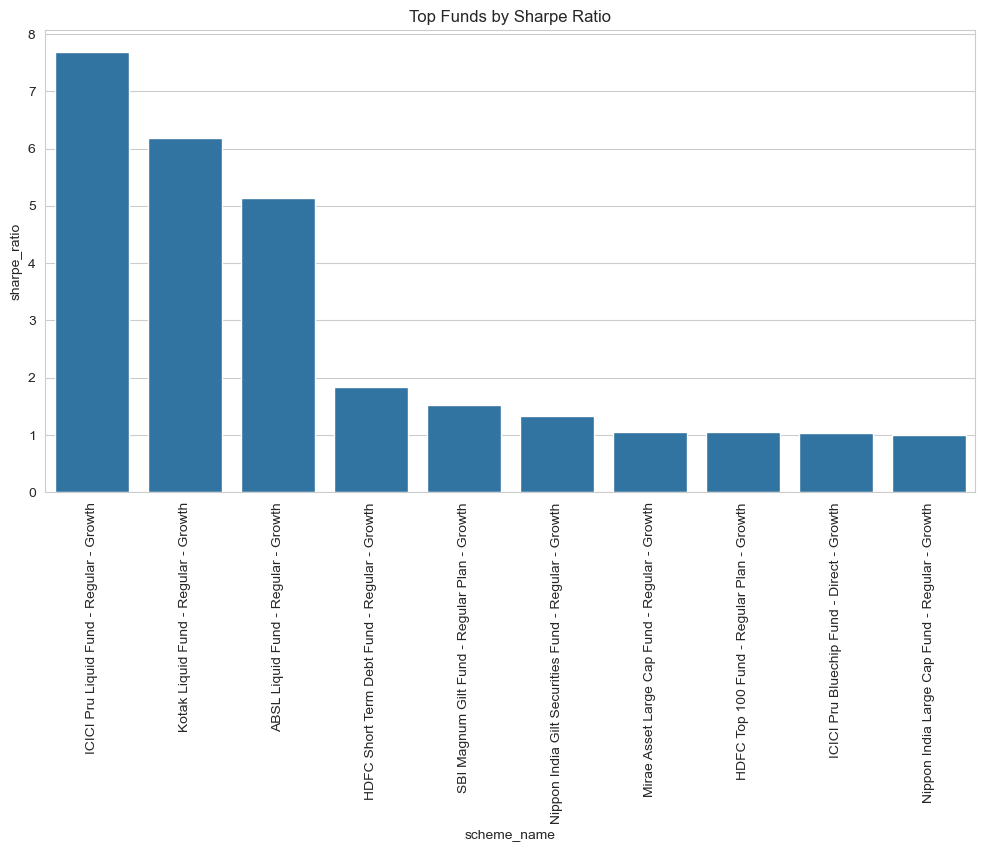

In [7]:

# 15. SHARPE RATIO ANALYSIS


top_sharpe = perf_df.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="scheme_name",
    y="sharpe_ratio"
)

plt.xticks(rotation=90)

plt.title("Top Funds by Sharpe Ratio")

plt.show()

In [22]:

print("1. NAV trends indicate strong 2023 market rally.")
print("2. Market corrections visible during 2024.")
print("3. SBI dominates total AUM contribution.")
print("4. SIP inflows show strong retail participation growth.")
print("5. Tier-1 cities contribute highest SIP investments.")
print("6. Younger investors dominate SIP participation.")
print("7. Equity-oriented categories attract major inflows.")
print("8. Certain funds show high positive NAV correlations.")
print("9. Lower expense ratio funds remain competitive.")
print("10. Technology and Financial sectors dominate allocation.")

1. NAV trends indicate strong 2023 market rally.
2. Market corrections visible during 2024.
3. SBI dominates total AUM contribution.
4. SIP inflows show strong retail participation growth.
5. Tier-1 cities contribute highest SIP investments.
6. Younger investors dominate SIP participation.
7. Equity-oriented categories attract major inflows.
8. Certain funds show high positive NAV correlations.
9. Lower expense ratio funds remain competitive.
10. Technology and Financial sectors dominate allocation.
